# What Drives Childhood Obesity? 
## An Explainable Machine Learning Analysis of London Wards

## Preparation

- [Github link](https://github.com/mixedmint/DSSS)

- Number of words: 1493

- Runtime: 305 seconds (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: Podman

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **xgboost-3.2.0**
    - **shap-0.51.0**

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

In [1]:
import time
start_time = time.time()

In [2]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.4f' % x)
import numpy as np
from matplotlib import pyplot 
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


Childhood obesity has emerged as a pressing global public health challenge, closely linked to severe lifelong comorbidities such as type II diabetes (Colmenarejo, 2020). In the UK, prevalence varies significantly across neighbourhoods and worsens dramatically with age, rising from approximately 10.5% in Reception to over 22.2% by Year 6 (NCMP, 2025). This issue is particularly acute in urban settings like London.

To mitigate this crisis, developing robust predictive models using multidimensional risk factors is crucial. Traditionally, statistical approaches such as linear and logistic regression have been widely employed to evaluate early life risk factors (Pei et al., 2013). However, childhood obesity is a complex condition driven by interacting individual and area-level characteristics, prompting a shift towards Machine Learning (ML) models capable of capturing nonlinear relationships. For instance, Hammond et al. (2019) demonstrated the superiority of Gradient Boosting over traditional regression, while Jeong et al. (2023) successfully utilised Random Forest coupled with SHAP to interpret social and environmental influences.

Despite these advancements, a critical research gap remains. Existing studies predominantly focus on single age cohorts or rely heavily on individual-level clinical data, with little comparative analysis of how area-level socioeconomic and built environment factors shift in predictive importance across developmental stages. Addressing this, the study employs MLR, RF, XGBoost, and SHAP to compare how ward-level characteristics drive childhood obesity differently between Reception and Year 6 cohorts in London.

## Research questions

[[ go back to the top ]](#Table-of-contents)

<div style="margin-left: 2em;">
<span style="font-family: monospace;">
    RQ1 | To what extent can multidimensional features (socioeconomic, demographic, health, and environmental exposure factors) accurately predict the obesity rates of children in different school years at the London ward level?
</span>
</div>

<div style="margin-left: 2em;">
<span style="font-family: monospace;">
    RQ2 | Within the optimal predictive model, which key features act as the most significant drivers of childhood obesity, and how do their marginal effects differ between the two age groups?
</span>
</div>

## Data

[[ go back to the top ]](#Table-of-contents)

### Data Source
The dependent variable is sourced from the London Ward-level [Prevalence of Childhood Obesity](https://data.london.gov.uk/dataset/prevalence-of-childhood-obesity-borough-ward-and-msoa-23g07/) dataset (2010/11–2012/13), which provides overweight and obesity prevalence for Reception and Year 6 cohorts across over 600 wards.

For independent variables, the [London Ward Atlas](https://data.london.gov.uk/dataset/ward-profiles-and-atlas-exprl/) was utilized due to its comprehensive coverage of area-level statistics. Due to privacy constraints associated with individual clinical data, this study focuses exclusively on macroscopic neighborhood characteristics.

### Feature Selection
Guided by recent literature, feature selection was conducted across four dimensions: **demographic, socioeconomic, health condition, and environmental exposure**. While Mazza et al. (2025) emphasize the predictive power of standard socioeconomic and demographic indicators, this study further incorporates environmental and health behavior metrics to broaden the analytical scope, an approach supported by Salerno et al. (2024). 

This theoretically driven selection yielded 23 initial predictors.

| Variable                            | Type         | Description                                                             |Year   |
|-------------------------------------|--------------|-------------------------------------------------------------------------|---|
|**Target Variables** |  |  |  |
| Childhood obesity rate: reception (aged 4-5 years) and year 6 (aged 10-11 years) | Numeric | The children obesity rate of wards  | 2010/11-2012/13 |
| | | | |
| **Demographic Features** |   |                                     |   |
| Median age | Numeric | Median age of wards | 2011 |
| Population under 15 years | Numeric | Percentage of population age 15 years or younger | 2013 |
| Population density | Numeric | Population density (persons per sq km) | 2011 |
| White population | Numeric | Percentage of White population | 2011 |
| Population borned in UK  | Numeric  | Percentage of population borned in UK                                    | 2011  |
| | | | |
| **Socioeconomic Features**  |   |                                   |   |
| Median house price | Numeric | The median house price (UK pounds) of wards | 2011 |
| Homeownership | Numeric | Percentage of owner-occupied housing units | 2011 |
| Median household income | Numeric | The income (UK pound) where half of households in a county earn more and half of households earn less | 2012 |
| Children in Single-Parent Household | Numeric  | Percentage of children that live in a household headed by a single parent | 2011 |
| Parents unempolyment | Numeric | Percentage of households with no adults in employment with dependent children | 2011 |
| Higher education qulifications | Numeric | Percentage of people with level 4 qulifications and above | 2011 |
| Housing benefits claimants | Numeric | Percentage of households that claim housing benefits | 2011 |
| Children in poverty | Numeric | Percentage of people under age 16 in poverty | 2011 |
| Crime rate | Numeric | Crime rate of wards | 2011 |
| Indices of Deprivation | Numeric | Average scores of Indices of Deprivation | 2010 |
| Income Deprivation Affecting Children Index (IDACI) | Numeric | Average scores of IDACI | 2010 |
| | | | |
| **Health Condition Features**  |   |                                   |  |
| Life expectancy  | Numeric  | Average life expectancy at birth of all genders | 2009-2013  |
| Subjective well-being average score  | Numeric | Subjective well-being average score of wards | 2011-2013 |
| People with Bad or Very Bad Health | Numeric | Percentage of people with Bad or Very Bad Health | 2011 |
| | | | |
| **Environmental Exposure Features**  |   |                                   |  |
| Air emissions | Numeric  | Annual Mean of Nitrogen Oxide (NOx) | 2011  |
| Deficiency in access to green space | Numeric | Percentage of homes with deficiency in access to nature | 2012 |
| Public Transport Accessibility | Numeric | Average PTAL score | 2011 |
| Car access | Numeric | Cars per household | 2011 |

### Data Pre-processing and Presentation
The workflow was executed in the following steps:

1.	_Target Formatting & Cleaning_: Converted target variables to numeric formats (coercing character errors to NaN) and removed rows with missing entries.
2.	_Feature Engineering_: Computed proportional rates from absolute feature counts to standardize the scale across different wards.
3.	_Data Integration_: Merged the cleaned feature set ($X$) and target variables ($y$) via an inner join based on the unique Ward Code.
4.	_Exploratory Data Analysis (EDA)_: Conducted statistical summaries and spatial mapping to contextualize the data structures and variable distributions.

#### Prevalence of Childhood Obesity

In [3]:
# Load childhood obesity prvalance data
obesity = pd.read_csv("https://raw.githubusercontent.com/mixedmint/DSSS/refs/heads/main/data/children_obesity_2010-2013.csv")
obesity.head(10)

,Code,Borough,Names,obesity rate % (age 4-5),obesity rate % (age 10-11)
0,E05000001,City of London,Aldersgate,s,s
1,E05000015,City of London,Cripplegate,s,s
2,E05000017,City of London,Farringdon Within,s,s
3,E05000021,City of London,Portsoken,s,s
4,E05000026,Barking and Dagenham,Abbey,15.1%,23.2%
5,E05000027,Barking and Dagenham,Alibon,9.6%,25.6%
6,E05000028,Barking and Dagenham,Becontree,12.1%,28.4%
7,E05000029,Barking and Dagenham,Chadwell Heath,12.1%,28.8%
8,E05000030,Barking and Dagenham,Eastbrook,10.9%,24.1%
9,E05000031,Barking and Dagenham,Eastbury,12.3%,24.3%


In [4]:
obesity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 628 entries, 0 to 627
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Code                        628 non-null    object
 1   Borough                     628 non-null    object
 2   Names                       628 non-null    object
 3   obesity rate % (age 4-5)    628 non-null    object
 4   obesity rate % (age 10-11)  628 non-null    object
dtypes: object(5)
memory usage: 24.7+ KB


In [5]:
# Since suppressed data is marked with `s` for privacy,
# the obesity rate columns are parsed as object instead of float.
# We will convert them to numeric types and drop any NaN rows

# First, simplify complex column names
obesity = obesity.rename({'obesity rate % (age 4-5)': 'Reception', 'obesity rate % (age 10-11)': 'Year 6'}, axis=1)

# Then convert obesity rate columns from strings to floats
cols_to_clean = ['Reception', 'Year 6']
for col in cols_to_clean:
    obesity[col] = pd.to_numeric(obesity[col].str.replace('%', ''), errors='coerce')

# Drop rows with NaN values and Borough column
obesity = obesity.dropna().drop(['Borough'], axis=1)

obesity.head()

,Code,Names,Reception,Year 6
4,E05000026,Abbey,15.1000,23.2000
5,E05000027,Alibon,9.6000,25.6000
6,E05000028,Becontree,12.1000,28.4000
7,E05000029,Chadwell Heath,12.1000,28.8000
8,E05000030,Eastbrook,10.9000,24.1000


In [6]:
# Check data types of obesity rates after processing
obesity.info()

<class 'pandas.core.frame.DataFrame'>
Index: 609 entries, 4 to 626
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Code       609 non-null    object 
 1   Names      609 non-null    object 
 2   Reception  609 non-null    float64
 3   Year 6     609 non-null    float64
dtypes: float64(2), object(2)
memory usage: 23.8+ KB


#### Features

In [7]:
# Load features data
raw_features = pd.read_csv("https://raw.githubusercontent.com/mixedmint/DSSS/refs/heads/main/data/selected_ward_atlas.csv")
raw_features.head()

,New Code,Borough,Names,Median age,Aged 0-15,Population density,White,Mixed,Asian or Asian British,Black or Black British,...,% Highest level of qualification: Level 4 qualifications and above,Housing benefits claimants,Children in poverty,Crime rate,Air emissions,% homes with deficiency in access to nature,Public transport accessibility,Car access,Indices of Deprivation,IDACI
0,E09000001,City of London,City of London,39,7.5000,2312.5000,5799,289,940,193,...,68.4000,6.4593,13.9000,611.9000,94.8700,100.0000,7.6773,0.3859,12.1249,0.1197
1,E05000026,Barking and Dagenham,Abbey,29,25.2747,9884.6154,3596,585,5619,2621,...,34.5000,15.1958,34.5000,182.5681,53.7900,2.1644,5.8505,0.5477,32.7261,0.4386
2,E05000027,Barking and Dagenham,Alibon,32,25.9615,7464.2857,7275,362,743,1900,...,16.7000,19.0405,35.7000,91.3876,41.6900,71.7274,3.2588,0.8152,36.0662,0.3966
3,E05000028,Barking and Dagenham,Becontree,32,24.8963,8923.0769,6789,524,2009,2048,...,20.6000,16.9102,34.3000,98.7931,44.0000,17.1663,2.8520,0.8702,31.6865,0.3797
4,E05000029,Barking and Dagenham,Chadwell Heath,34,24.1379,2970.5882,6224,473,1560,1593,...,19.5000,14.8163,35.6000,97.4257,39.4700,63.5924,2.2610,0.9181,38.0445,0.4355


In [8]:
raw_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 36 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   New Code                                                              625 non-null    object 
 1   Borough                                                               625 non-null    object 
 2   Names                                                                 625 non-null    object 
 3   Median age                                                            625 non-null    int64  
 4   Aged 0-15                                                             625 non-null    float64
 5   Population density                                                    625 non-null    float64
 6   White                                                                 625 non-null    int64  
 7  

In [9]:
# Calculate the percentage of White population 
# Define ethnicity columns
ethnicity_cols = [
    'White', 
    'Mixed', 
    'Asian or Asian British', 
    'Black or Black British', 
    'Other'
]

# Calculate White population percentage
raw_features['White population'] = (raw_features['White'] / raw_features[ethnicity_cols].sum(axis=1))*100

# Drop the original data columns
raw_features = raw_features.drop(ethnicity_cols, axis=1)

raw_features['White population'].head()

0   78.6305
1   28.1245
2   70.0530
3   58.8047
4   62.1096
Name: White population, dtype: float64

In [10]:
# Calculate the percentage of population borned in UK
raw_features['Born in uk'] = (raw_features['Born in UK'] / raw_features[['Born in UK', 'Not Born in UK']].sum(axis=1))*100

# Drop the original data columns
raw_features = raw_features.drop(['Born in UK', 'Not Born in UK'], axis=1)

raw_features['Born in uk'].head()

0   63.3220
1   42.6951
2   75.3394
3   69.9437
4   75.2320
Name: Born in uk, dtype: float64

In [11]:
# Calculate the percentage of owner-occupied housing units (Homeownership)
# Define ownership columns
owenership_cols = [
    'Owned: Owned outright', 
    'Owned: Owned with a mortgage or loan (inc shared)', 
    'Social rented', 
    'Private rented', 
    'Rent Free'
]

# Define Owner-occupied housing columns
owned_cols = [
    'Owned: Owned outright', 
    'Owned: Owned with a mortgage or loan (inc shared)'
]

# Calculate Homeownership
raw_features['Homeownership'] = (raw_features[owned_cols].sum(axis=1) / raw_features[owenership_cols].sum(axis=1))*100

# Drop the original data columns
raw_features = raw_features.drop(owenership_cols, axis=1)

raw_features['Homeownership'].head()

0   42.5998
1   33.7927
2   46.5626
3   48.9362
4   54.4901
Name: Homeownership, dtype: float64

In [12]:
# Calculate the percentage of Children in Single-Parent Household
raw_features['Children in single-parent household'] = (raw_features['Lone parent'] / raw_features['All Households'])*100

# Drop the original data columns
raw_features = raw_features.drop(['Lone parent', 'All Households'], axis=1)

raw_features['Children in single-parent household'].head()

0    3.4892
1   14.1732
2   20.9519
3   20.5752
4   19.6854
Name: Children in single-parent household, dtype: float64

In [13]:
# Simplify complex column names
raw_features = raw_features.rename({'Subjective well-being average score': 'Well-being score',
                                    'People with Bad or Very Bad Health': 'People in bad health',
                                    '% of households with no adults in employment with dependent children': 'Parents unemployment', 
                                    '% Highest level of qualification: Level 4 qualifications and above': 'Higher education qualifications',
                                   '% homes with deficiency in access to nature': 'Green deficit'},
                                   axis=1)

In [14]:
raw_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 26 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   New Code                             625 non-null    object 
 1   Borough                              625 non-null    object 
 2   Names                                625 non-null    object 
 3   Median age                           625 non-null    int64  
 4   Aged 0-15                            625 non-null    float64
 5   Population density                   625 non-null    float64
 6   Life expectancy                      625 non-null    float64
 7   Well-being score                     625 non-null    float64
 8   People in bad health                 625 non-null    float64
 9   Median house price                   625 non-null    float64
 10  Median household income              625 non-null    int64  
 11  Parents unemployment            

#### Joining the Datasets

In [15]:
# Merge two databases based on the ward code
df = pd.merge(obesity, raw_features, left_on='Code', right_on='New Code', how='inner')

# Remove duplicate and unnecessary columns
df = df.drop(['New Code', 'Borough', 'Names_y'], axis=1).rename({'Names_x': 'Names'}, axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 27 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Code                                 609 non-null    object 
 1   Names                                609 non-null    object 
 2   Reception                            609 non-null    float64
 3   Year 6                               609 non-null    float64
 4   Median age                           609 non-null    int64  
 5   Aged 0-15                            609 non-null    float64
 6   Population density                   609 non-null    float64
 7   Life expectancy                      609 non-null    float64
 8   Well-being score                     609 non-null    float64
 9   People in bad health                 609 non-null    float64
 10  Median house price                   609 non-null    float64
 11  Median household income         

In [16]:
df.describe()

,Reception,Year 6,Median age,Aged 0-15,Population density,Life expectancy,Well-being score,People in bad health,Median house price,Median household income,...,Air emissions,Green deficit,Public transport accessibility,Car access,Indices of Deprivation,IDACI,White population,Born in uk,Homeownership,Children in single-parent household
count,609.0000,609.0000,609.0000,609.0000,609.0000,609.0000,609.0000,609.0000,609.0000,609.0000,...,609.0000,609.0000,609.0000,609.0000,609.0000,609.0000,609.0000,609.0000,609.0000,609.0000
mean,10.4685,21.5767,34.2463,19.7783,8014.4102,81.8959,7.6307,4.9752,308727.6125,38680.7553,...,51.7017,25.9433,3.6154,0.8469,25.2377,0.3126,60.8507,64.3351,51.0751,12.7509
std,3.1981,5.0440,4.0056,3.5749,4757.4747,2.1672,0.3179,1.2290,124331.3091,6483.0899,...,11.2178,30.3740,1.2900,0.3272,11.1901,0.1513,18.9834,13.6356,18.4633,4.4317
min,2.6000,6.2000,26.0000,6.8670,177.5862,75.9843,6.7803,2.1000,120000.0000,25090.0000,...,30.6200,0.0000,1.2781,0.2333,4.8771,0.0440,6.2579,31.5475,13.7183,4.3684
25%,8.3000,18.5000,31.0000,17.7570,4528.5714,80.4131,7.3955,4.1000,225500.0000,33540.0000,...,43.6300,0.0874,2.6182,0.5595,15.6900,0.1903,47.3794,54.6895,35.1711,9.3249
50%,10.5000,22.2000,33.0000,19.6078,6750.0000,81.8663,7.6389,4.9000,275000.0000,38060.0000,...,49.5600,12.4642,3.2476,0.8267,24.7347,0.3131,63.1062,63.0925,49.8532,12.1409
75%,12.5000,25.4000,37.0000,21.8750,10735.2941,83.3154,7.8756,5.8000,356250.0000,42880.0000,...,57.6700,42.8724,4.3649,1.1164,33.6121,0.4239,76.0167,73.8737,65.7778,15.5513
max,20.9000,35.7000,46.0000,32.4000,29375.0000,89.7823,8.5547,10.9000,1200000.0000,58400.0000,...,99.7000,100.0000,7.9594,1.7051,54.7832,0.7791,95.8698,94.9452,90.9864,31.4271


#### Exploratory Data Analysis (EDA)

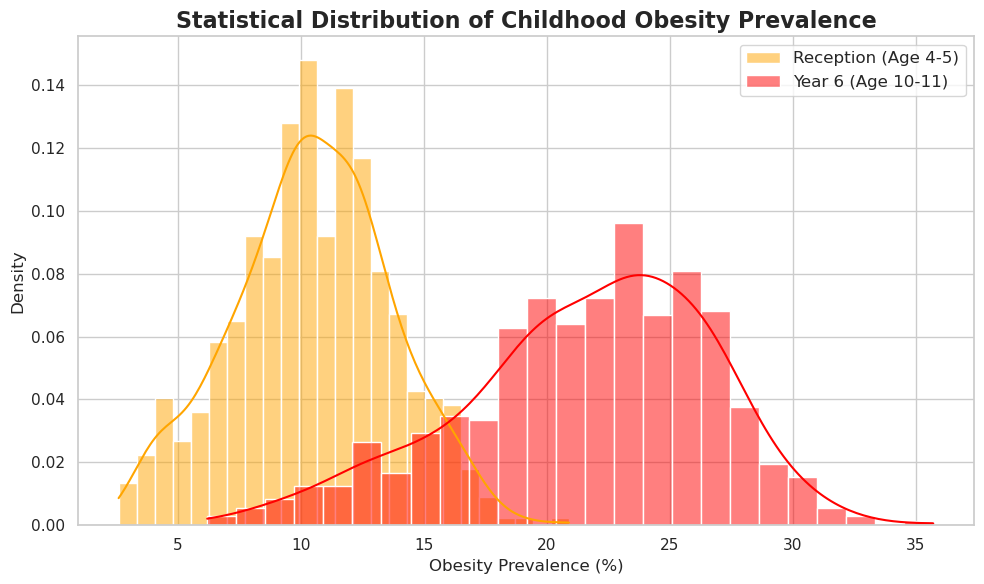

In [17]:
# Plot statistical disttribution chart of obesity prevalence 

# Set figure size and theme
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Reception obesity histogram+KDE
sns.histplot(
    df['Reception'], 
    kde=True, 
    color='orange', 
    label='Reception (Age 4-5)', 
    stat='density', 
    alpha=0.5,      
    bins=25
)

# Year 6 obesity histogram+KDE
sns.histplot(
    df['Year 6'], 
    kde=True, 
    color='red', 
    label='Year 6 (Age 10-11)', 
    stat='density', 
    alpha=0.5, 
    bins=25
)

# Configure title and axis labels
plt.title('Statistical Distribution of Childhood Obesity Prevalence', fontsize=16, fontweight='bold')
plt.xlabel('Obesity Prevalence (%)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Add legend
plt.legend(fontsize=12)

# Set layout and show plot
plt.tight_layout()
plt.show()

The rightward shift of the Year 6 peak indicates increased obesity prevalence with age, with both distributions approximately normally distributed.

In [18]:
# Then I will plot choropleth maps of childhood obesity rates to see their spatial distribution patterns

# I downloaded 2011 UK Ward Boundaries files from ONS
# and selected all London wards:

# uk_wards = gpd.read_file('data/Wards_December_2011_GCB.geojson')
# lookup_table = pd.read_csv('data/Wards_and_Local_Authorities_(2011)_to_Wards_and_Local_Authorities_(2022)_Lookup_in_England_and_Wales.csv')
# lookup_table = lookup_table.drop_duplicates(subset=['WD11CD'])
# merged_wards = uk_wards.merge(lookup_table, left_on='wd11cd', right_on='WD11CD', how='left')
# london_wards = merged_wards[merged_wards['LAD11CD'].str.startswith('E09', na=False)]
# columns_to_drop = ['WD11CD', 'WD11NM', 'WD22CD', 'WD22NM', 'LAD22CD', 'LAD22NM']
# london_wards = london_wards.drop(columns=columns_to_drop)

# Load London Ward geojson file
london_map = gpd.read_file("https://raw.githubusercontent.com/mixedmint/DSSS/refs/heads/main/data/london_wards_2011.geojson")
london_map.info()


# Merge london_map and dataset
geo_df = london_map.merge(df, left_on='wd11cd', right_on='Code', how='left')

# Set CRS
geo_df = geo_df.to_crs(epsg=27700)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   OBJECTID  649 non-null    int32   
 1   wd11cd    649 non-null    object  
 2   wd11nm    649 non-null    object  
 3   LAD11NM   649 non-null    object  
 4   geometry  649 non-null    geometry
dtypes: geometry(1), int32(1), object(3)
memory usage: 22.9+ KB


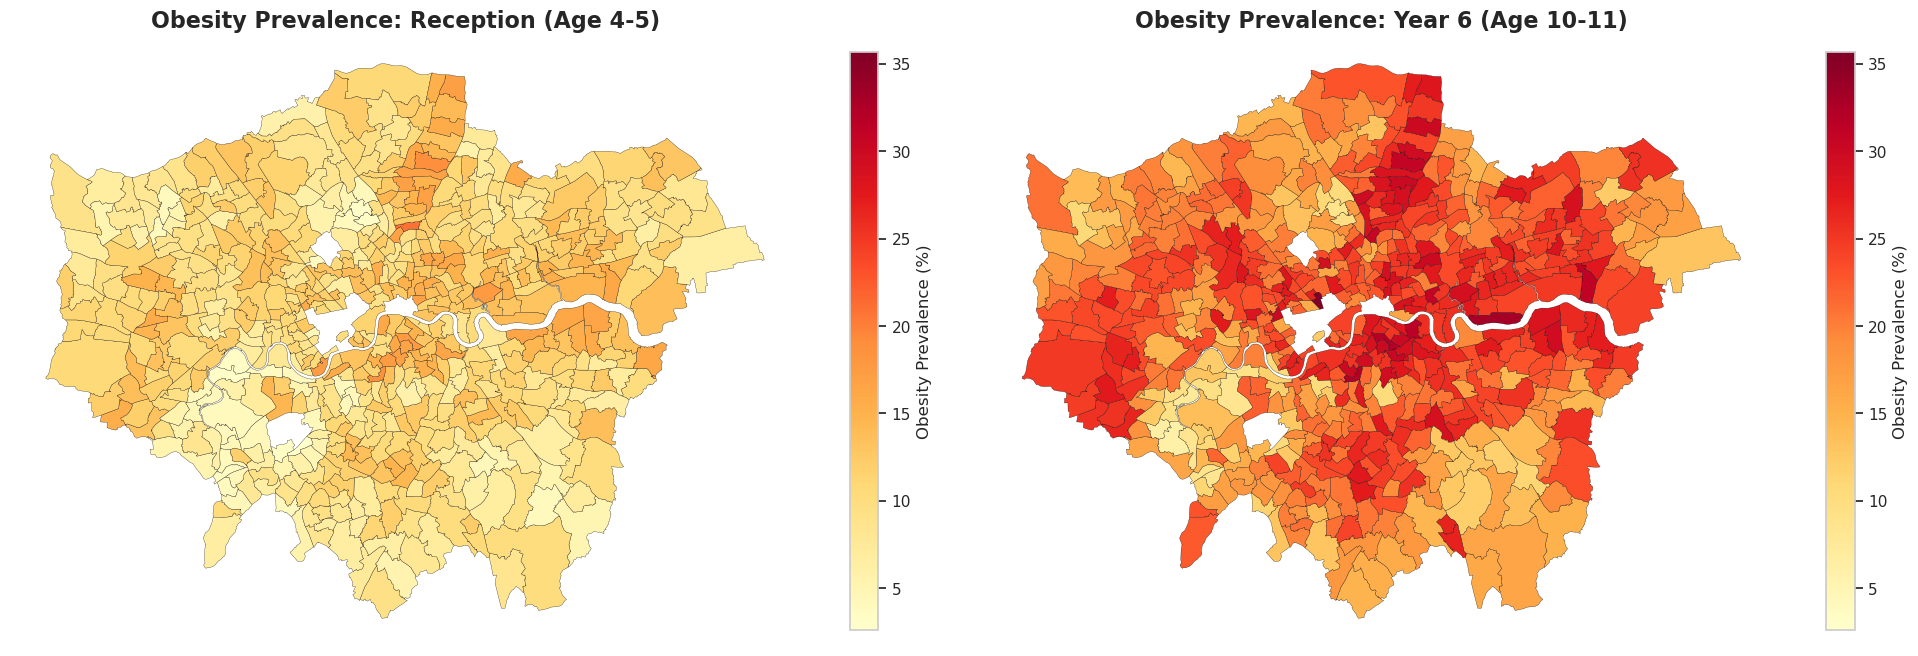

In [19]:
# Plot childhood obesity prevalance choropleth maps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

vmin = min(geo_df['Reception'].min(), geo_df['Year 6'].min())
vmax = max(geo_df['Reception'].max(), geo_df['Year 6'].max())

plot_kwds = {
    'cmap': 'YlOrRd',         
    'vmin': vmin,             
    'vmax': vmax,            
    'edgecolor': 'black',      
    'linewidth': 0.2,         
    'legend': True,
    'legend_kwds': {'shrink': 0.6, 'label': 'Obesity Prevalence (%)'} 
}

# Reception obesity map
geo_df.plot(column='Reception', ax=ax1, **plot_kwds)
ax1.set_title('Obesity Prevalence: Reception (Age 4-5)', fontsize=16, fontweight='bold')
ax1.axis('off')

# Year 6 obesity map
geo_df.plot(column='Year 6', ax=ax2, **plot_kwds)
ax2.set_title('Obesity Prevalence: Year 6 (Age 10-11)', fontsize=16, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

The maps also reveal a stark age-related increase in obesity, with high-prevalence clusters persistently concentrated in central-eastern London wards.

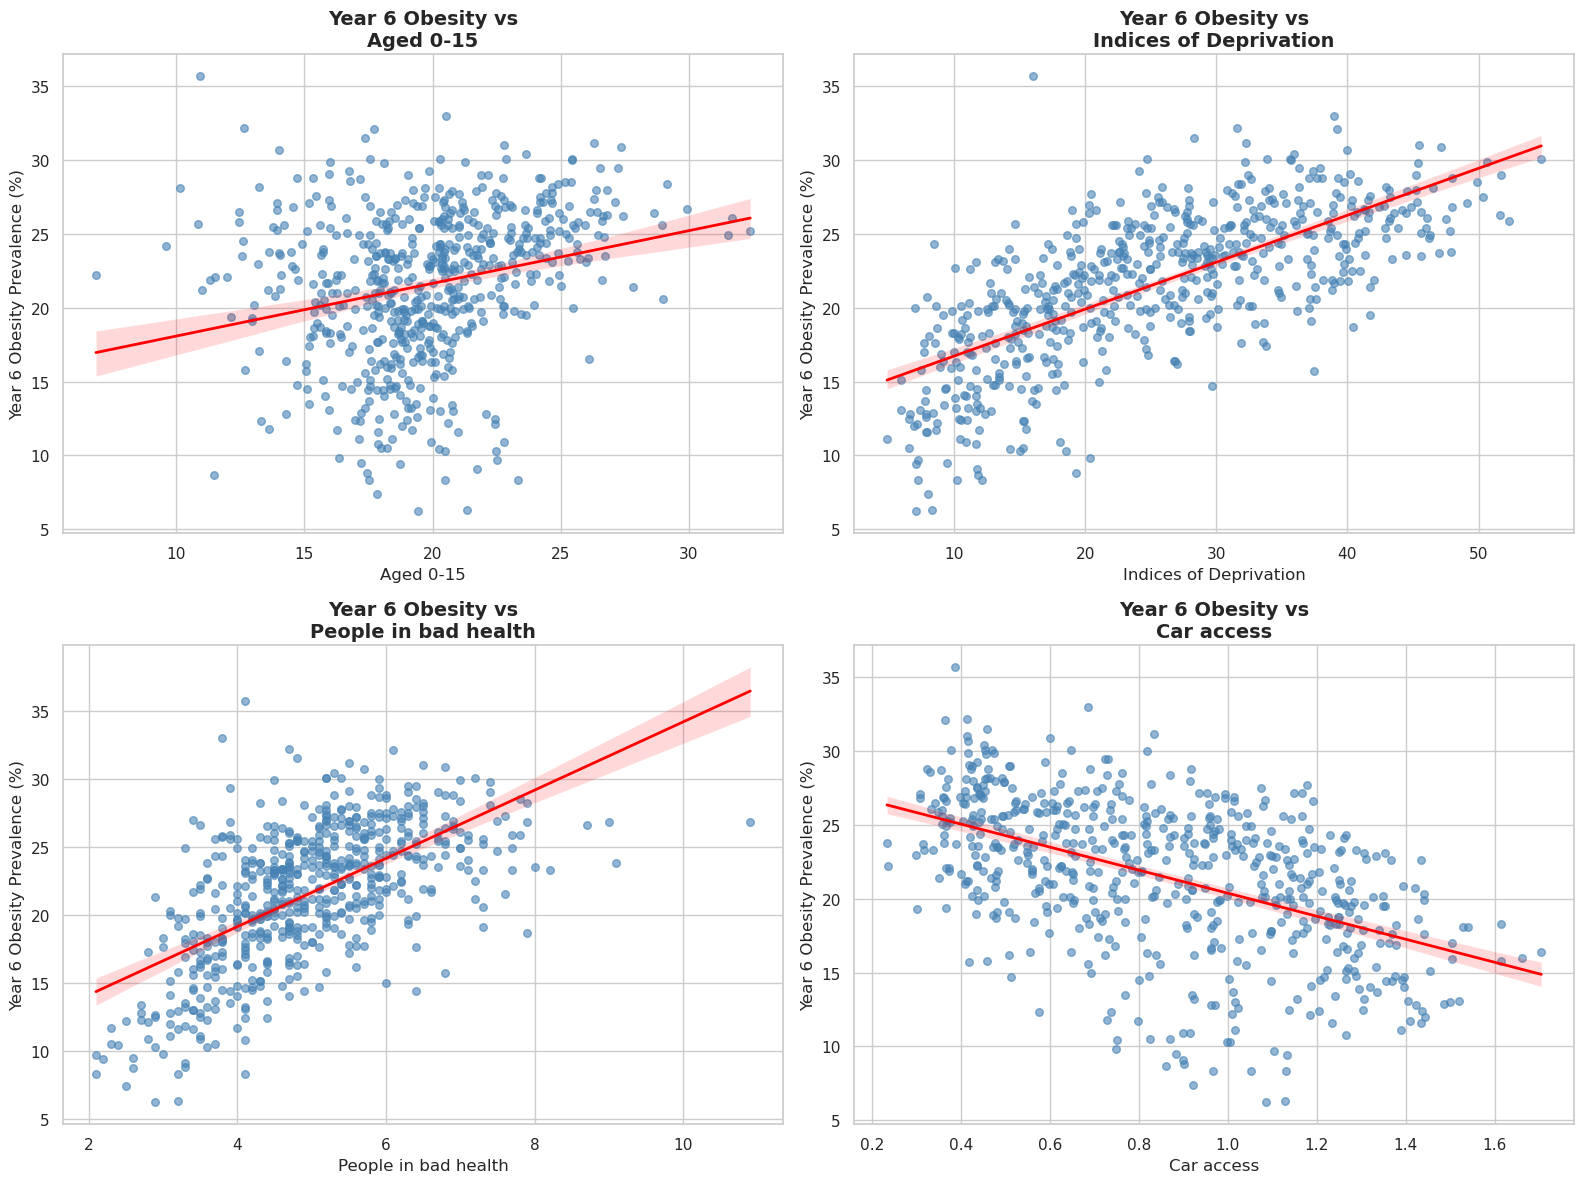

In [20]:
# Plot scatter plots to explore the correlation between obesity prevalence and features

# Since we have 23 features in total
# Plotting all of them would be visually overwhelming and difficult to interpret
# Therefore, we select 4 representative features
selected_features = [
    'Aged 0-15',                 # From demographic dimension      
    'Indices of Deprivation',    # From socioeconomic dimension            
    'People in bad health',      # From health condition dimension
    'Car access'                 # From environmental exposure dimension
]

# Set figure size and theme
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() 

sns.set_theme(style="whitegrid")

# Iterate through each selected feature to plot its relationship with Year 6 obesity
for i, feature in enumerate(selected_features):
    sns.regplot(
        data=df, 
        x=feature, 
        y='Year 6',  # Using Year 6 as the target variable for demonstration as it exhibits more significant variance
        ax=axes[i],
        scatter_kws={'alpha': 0.6, 'color': 'steelblue', 's': 30}, 
        line_kws={'color': 'red', 'linewidth': 2}                  
    )
    
    # Configure titles and axis labels for each subplot
    axes[i].set_title(f'Year 6 Obesity vs\n{feature}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Year 6 Obesity Prevalence (%)', fontsize=12)

plt.tight_layout()
plt.show()

The scatter plots reveal distinct linear patterns across all four dimensions. Indices of Deprivation and People in bad health show the strongest positive associations with Year 6 obesity prevalence, while Car access exhibits a negative relationship, likely because car ownership acts as a proxy for higher socioeconomic status and lower deprivation. Aged 0-15 shows a weaker positive trend. 

However, considerable scatter around all regression lines implies the presence of nonlinear dynamics and interaction effects that simple linear models cannot fully capture. **This motivates the use of MLR as an interpretable baseline, alongside RF and XGBoost to model these more complex structures.**

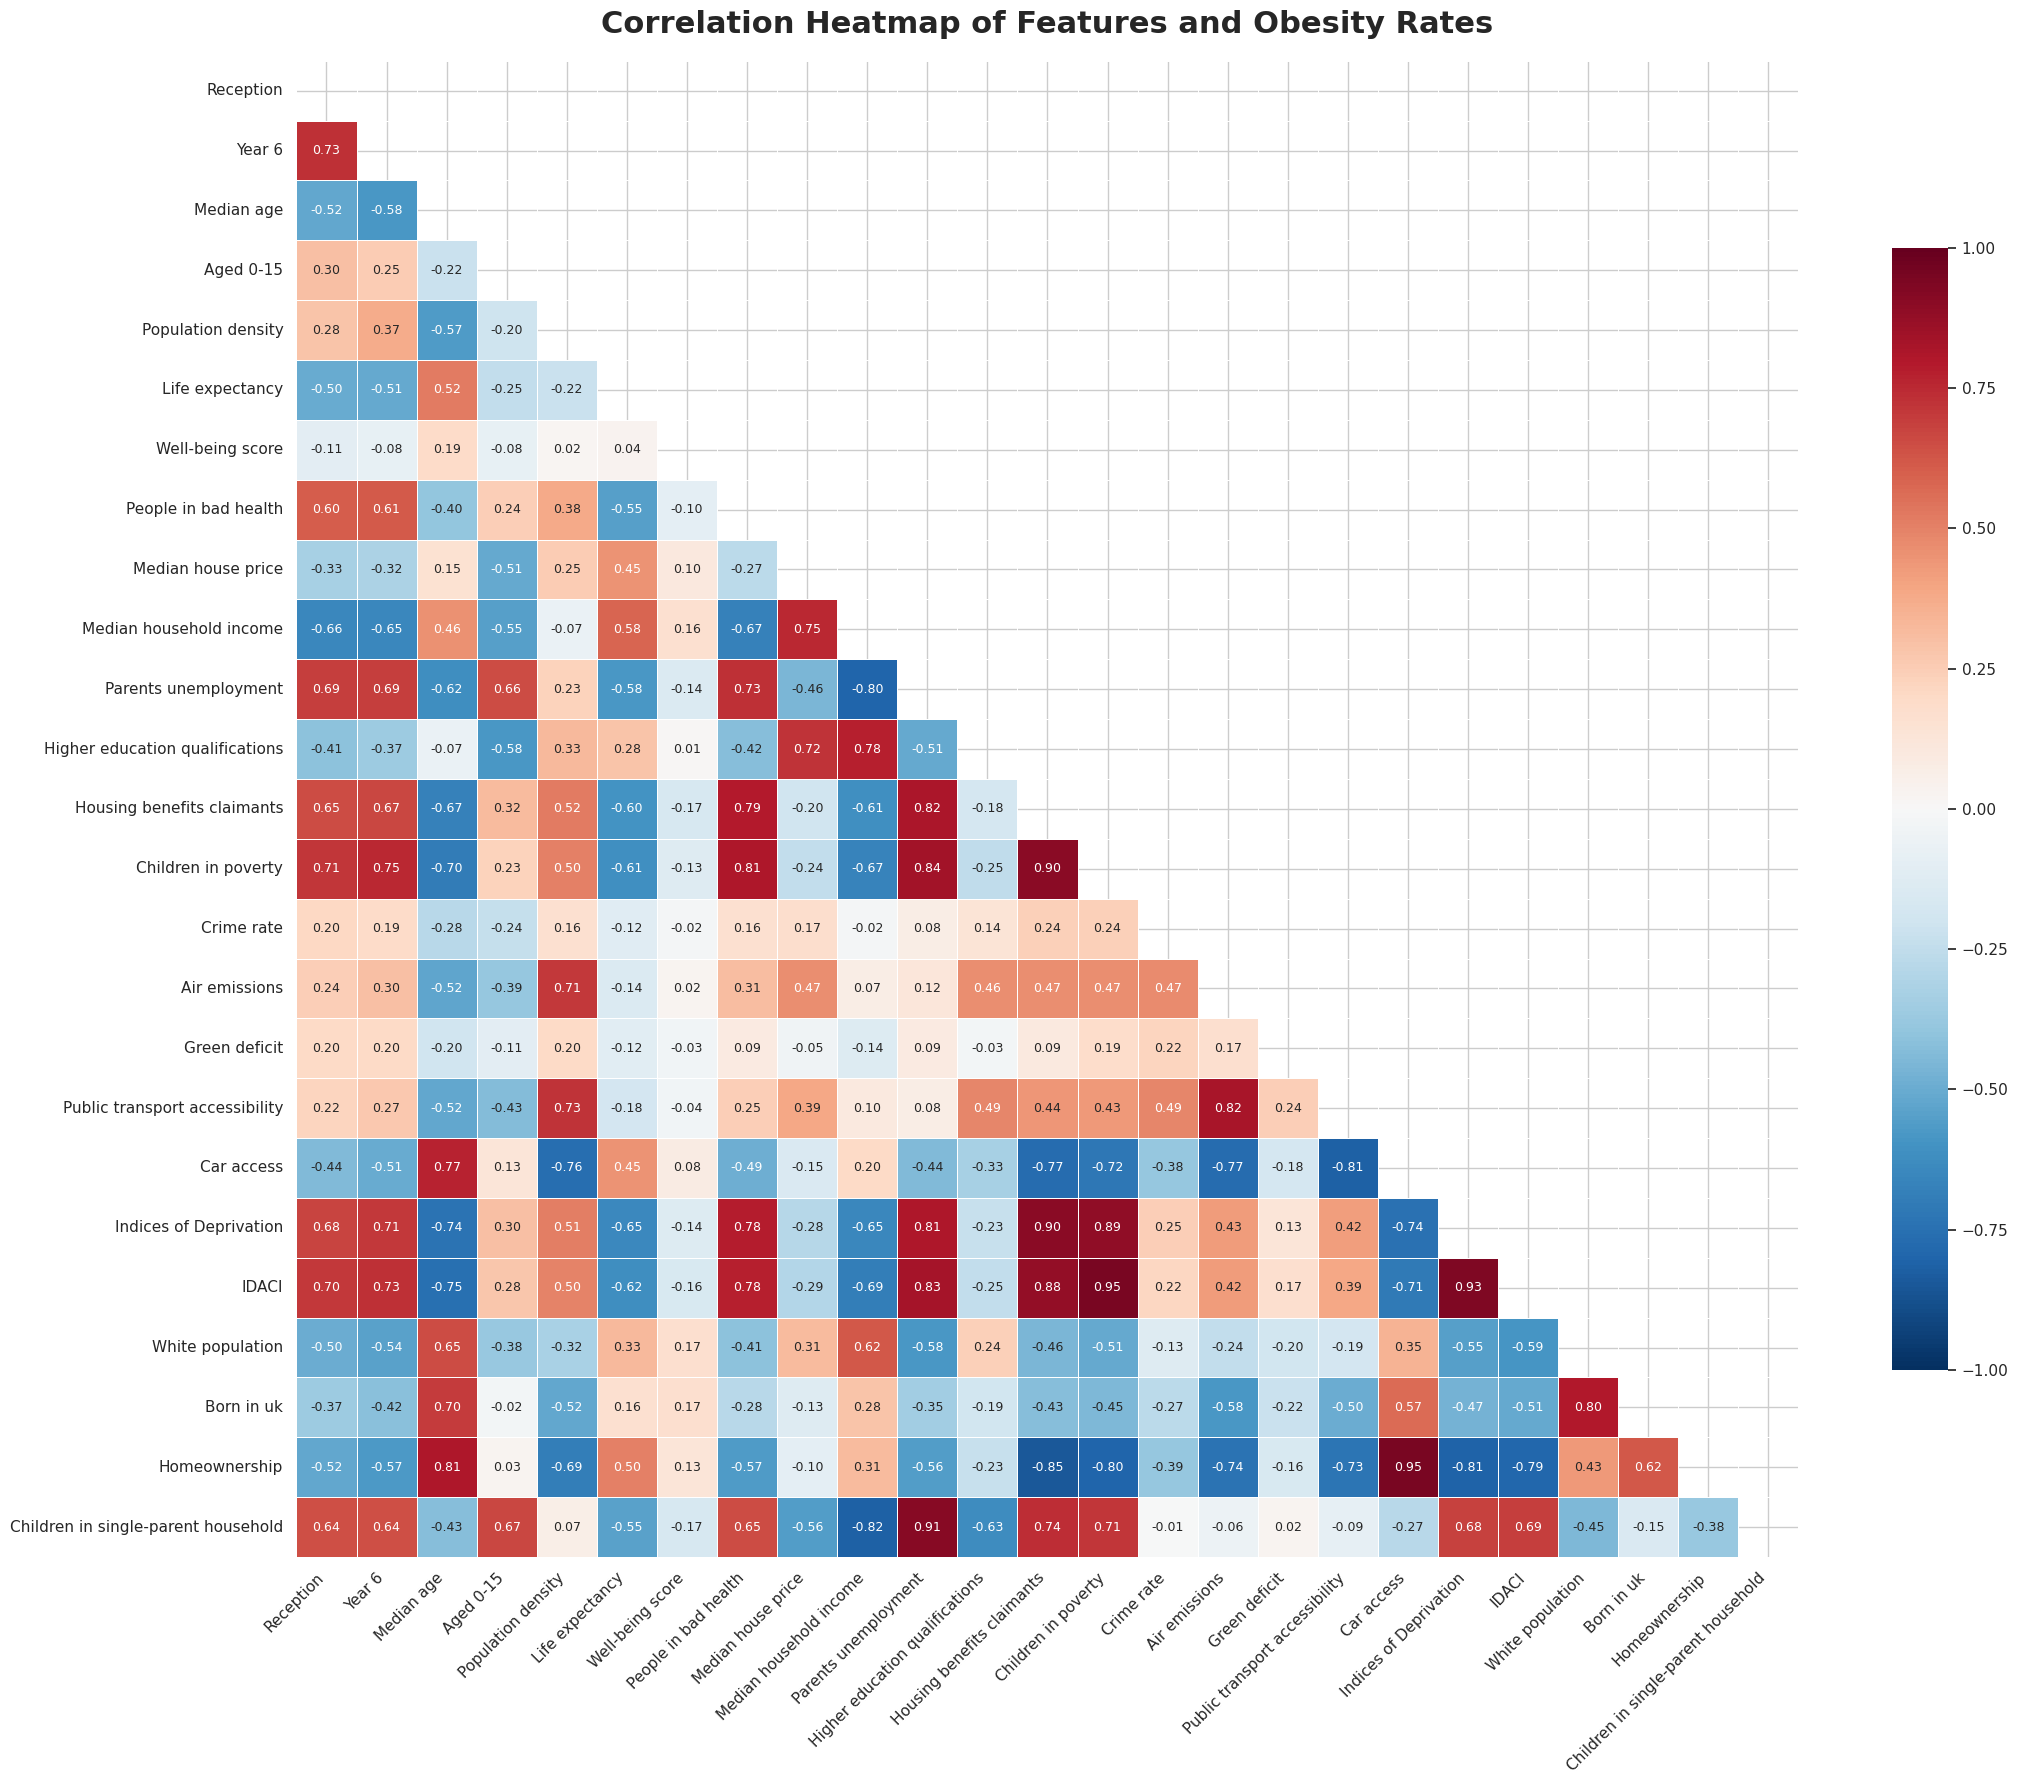

In [21]:
# Correlation Heatmap
# Using a lower-triangle heatmap for better readability with 23 features

# Filter numeric features (exclude strings, codes, or geometry columns)
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute the Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set figure size
plt.figure(figsize=(22, 18))

# Plot the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,            
    cmap='RdBu_r',         
    annot=True,           
    fmt=".2f",             
    annot_kws={"size": 9},   
    linewidths=0.5,       
    vmin=-1, vmax=1,       
    cbar_kws={"shrink": .75} 
)

# Set title and axis labels
plt.title('Correlation Heatmap of Features and Obesity Rates', 
          fontsize=22, fontweight='bold', pad=20)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

The heatmap reveals that IDACI, Indices of Deprivation and Children in poverty are the strongly correlated with obesity. However, these variables are also heavily inter-correlated. IDACI and Indices of Deprivation share a coefficient of 0.95, indicating severe **multicollinearity**. To address this, **VIF analysis is applied to iteratively remove redundant features prior to modelling**.

## Methodology

[[ go back to the top ]](#Table-of-contents)

This study employs a four-stage analytical pipeline to address research questions.

To address RQ1, the pipeline begins with **Variance Inflation Factor (VIF)** analysis, which iteratively removes features exceeding a threshold of 10, ensuring retained predictors are sufficiently independent and regression coefficients remain reliable. **Multiple Linear Regression (MLR)** is then applied as an interpretable linear baseline, where coefficient estimates and p-values quantify each feature's linear contribution to obesity prevalence. Subsequently, **Random Forest (RF) and XGBoost** are employed to capture nonlinear relationships and feature interactions that MLR cannot model. Both are optimised via 5-fold cross-validation with GridSearchCV, and their predictive performance (R², RMSE) is compared against MLR to assess whether nonlinear models offer meaningful improvements.

To address RQ2, **SHAP** is applied to the best-performing model, decomposing its predictions into individual feature contributions. This transforms the otherwise opaque tree-based models into interpretable outputs, enabling a direct comparison of the marginal effects of key drivers between the Reception and Year 6 cohorts.

<center>
<img src="https://raw.githubusercontent.com/mixedmint/DSSS/refs/heads/main/flow.png" width="650">
<center>

#### Variance Inflation Factor (VIF)

In [22]:
features_list = [
    'Median age', 'Aged 0-15', 'Population density', 'Life expectancy', 'Well-being score',
    'People in bad health', 'Median house price', 'Median household income', 'Parents unemployment',
    'Higher education qualifications', 'Housing benefits claimants', 'Children in poverty', 'Crime rate', 
    'Air emissions', 'Green deficit', 'Public transport accessibility', 'Car access', 
    'Indices of Deprivation', 'IDACI', 'White population', 'Born in uk', 
    'Homeownership', 'Children in single-parent household'
]

# Extract feature dataframe and drop any missing values
X = df[features_list].copy()
X = X.dropna()

# Define a function to iteratively calculate VIF and filter features
def calculate_vif_and_filter(X, threshold=5.0):
    X_with_const = add_constant(X)
    
    dropped_features = []
    
    while True:
        # Calculate VIF for all current features
        vif_data = pd.DataFrame()
        vif_data["Feature"] = X_with_const.columns
        vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) 
                           for i in range(X_with_const.shape[1])]

        # Exclude the constant term
        vif_features = vif_data[vif_data['Feature'] != 'const']
        
        # Identify the feature with the highest VIF
        max_vif_row = vif_features.loc[vif_features['VIF'].idxmax()]
        max_vif_value = max_vif_row['VIF']
        max_vif_feature = max_vif_row['Feature']
        
        # Drop the feature if its VIF exceeds the threshold
        if max_vif_value > threshold:
            print(f"Dropping: {max_vif_feature} (VIF = {max_vif_value:.2f})")
            X_with_const = X_with_const.drop(columns=[max_vif_feature])
            dropped_features.append(max_vif_feature)
        else:
            break
            
    # Return the final selected features, the VIF dataframe, and dropped features
    final_vif = vif_data[vif_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False)
    return list(final_vif['Feature']), final_vif, dropped_features

# Set the VIF threshold and execute the function
vif_threshold = 10.0
final_features, final_vif_df, dropped = calculate_vif_and_filter(X, threshold=vif_threshold)

# Print final results
print("VIF threshold:", vif_threshold)
print("Number of VIF-selected features:", len(final_features))
display(final_vif_df)

Dropping: Homeownership (VIF = 30.93)
Dropping: Median household income (VIF = 27.70)
Dropping: Children in poverty (VIF = 25.37)
Dropping: Car access (VIF = 20.75)
Dropping: Parents unemployment (VIF = 19.59)
Dropping: Housing benefits claimants (VIF = 14.24)
Dropping: IDACI (VIF = 10.99)
VIF threshold: 10.0
Number of VIF-selected features: 16


,Feature,VIF
15,Born in uk,8.1857
13,Indices of Deprivation,7.1247
14,White population,7.0609
1,Median age,5.8269
10,Air emissions,5.3133
12,Public transport accessibility,4.9229
16,Children in single-parent household,4.6785
8,Higher education qualifications,4.6367
6,People in bad health,4.4704
7,Median house price,3.8860


#### Multiple Linear Regression (MLR)
##### For Reception

In [23]:
X = df[final_features]
y_rec = df['Reception']

# Drop missing values to ensure X and y maintain consistent lengths
mlr_data_rec = pd.concat([X, y_rec], axis=1).dropna()
X_clean_rec = mlr_data_rec[final_features]
y_clean_rec = mlr_data_rec['Reception']

# Split data into training (80%) and testing (20%) sets
# I asked Gemini for advice
# This establishes a fair baseline comparison against non-linear models (RF/XGBoost) later
X_train_rec, X_test_rec, y_train_rec, y_test_rec = train_test_split(
    X_clean_rec, y_clean_rec, test_size=0.2, random_state=42
)

# Build the MLR model
X_train_rec_sm = sm.add_constant(X_train_rec)
X_test_rec_sm = sm.add_constant(X_test_rec)

mlr_rec = sm.OLS(y_train_rec, X_train_rec_sm).fit()

# Print statistical summary
print(mlr_rec.summary())

# Predict on the test set to evaluate model performance
y_pred_mlr_rec = mlr_rec.predict(X_test_rec_sm)

# Calculate and print R² and RMSE
rmse_mlr_rec = np.sqrt(mean_squared_error(y_test_rec, y_pred_mlr_rec))
r2_mlr_rec = r2_score(y_test_rec, y_pred_mlr_rec)

print(f"Reception MLR — R²: {r2_mlr_rec:.4f}, RMSE: {rmse_mlr_rec:.4f}")

                            OLS Regression Results                            
Dep. Variable:              Reception   R-squared:                       0.598
Model:                            OLS   Adj. R-squared:                  0.584
Method:                 Least Squares   F-statistic:                     43.61
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           3.20e-82
Time:                        20:28:08   Log-Likelihood:                -1033.2
No. Observations:                 487   AIC:                             2100.
Df Residuals:                     470   BIC:                             2172.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

The Reception MLR model achieves a test R² of 0.574 (RMSE=2.117), explaining 57.4% of variance in ward-level obesity prevalence. Statistically significant predictors (p<0.05) include Indices of Deprivation (β=0.060), Children in single-parent household (β=0.162), and Public transport accessibility (β=0.357) as positive drivers, while Higher education qualifications (β=-0.116) and Aged 0-15 (β=-0.208) show protective negative associations.

##### For Year 6

In [24]:
y_yr6 = df['Year 6']

mlr_data_yr6 = pd.concat([X, y_yr6], axis=1).dropna()
X_clean_yr6 = mlr_data_yr6[final_features]
y_clean_yr6 = mlr_data_yr6['Year 6']

X_train_yr6, X_test_yr6, y_train_yr6, y_test_yr6 = train_test_split(
    X_clean_yr6, y_clean_yr6, test_size=0.2, random_state=42
)

X_train_yr6_sm = sm.add_constant(X_train_yr6)
X_test_yr6_sm = sm.add_constant(X_test_yr6)

mlr_yr6 = sm.OLS(y_train_yr6, X_train_yr6_sm).fit()

print(mlr_yr6.summary())

y_pred_mlr_yr6 = mlr_yr6.predict(X_test_yr6_sm)

rmse_mlr_yr6 = np.sqrt(mean_squared_error(y_test_yr6, y_pred_mlr_yr6))
r2_mlr_yr6 = r2_score(y_test_yr6, y_pred_mlr_yr6)
print(f"Year 6 MLR — R²: {r2_mlr_yr6:.4f}, RMSE: {rmse_mlr_yr6:.4f}")

                            OLS Regression Results                            
Dep. Variable:                 Year 6   R-squared:                       0.637
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     51.51
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.62e-92
Time:                        20:28:08   Log-Likelihood:                -1238.2
No. Observations:                 487   AIC:                             2510.
Df Residuals:                     470   BIC:                             2582.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

The Year 6 MLR outperforms its Reception counterpart (test R²=0.676, RMSE=2.720), suggesting ward-level features are more predictive of obesity at age 10-11. Significant positive predictors include Indices of Deprivation (β=0.085), Children in single-parent household (β=0.401), and Well-being score (β=1.051), while Higher education qualifications (β=-0.142), Aged 0-15 (β=-0.355), and Median age (β=-0.226) exhibit significant negative associations.

#### Random Forest (RF)
##### For Reception

Reception RF — Starting CV and Hyperparameter Search...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters:
 - max_depth: None
 - min_samples_leaf: 1
 - min_samples_split: 5
 - n_estimators: 300
Reception RF — R²: 0.5788, RMSE: 2.1037


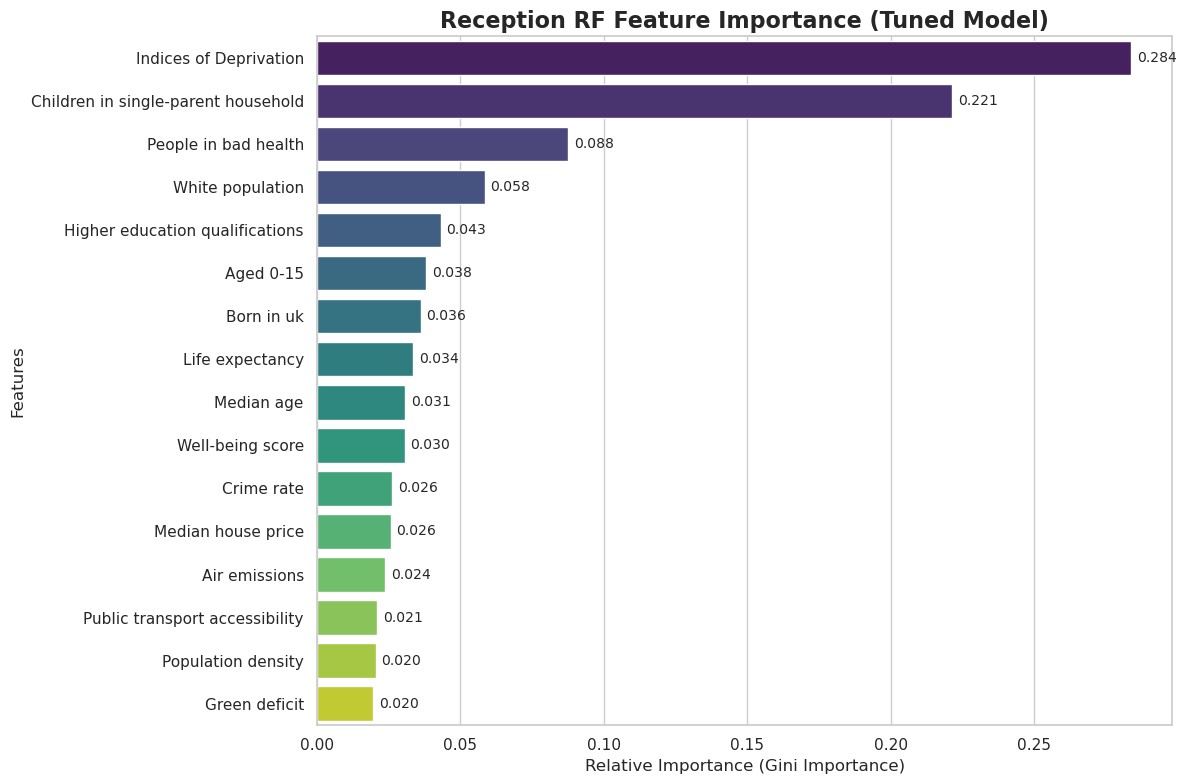

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the base Random Forest model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Configure 5-Fold Cross-Validation
print("Reception RF — Starting CV and Hyperparameter Search...")
grid_search_rf_rec = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='r2',
    verbose=1
)

# Fit GridSearchCV on the training data
grid_search_rf_rec.fit(X_train_rec, y_train_rec)

# Extract the best model and parameters found by CV
best_rf_rec = grid_search_rf_rec.best_estimator_

print("\nBest Parameters:")
for key, value in grid_search_rf_rec.best_params_.items():
    print(f" - {key}: {value}")

# Perform final predictions on the test set using the best model
y_pred_rf_rec = best_rf_rec.predict(X_test_rec)

# Calculate and print evaluation metrics
rmse_rf_rec = np.sqrt(mean_squared_error(y_test_rec, y_pred_rf_rec))
r2_rf_rec = r2_score(y_test_rec, y_pred_rf_rec)

print(f"Reception RF — R²: {r2_rf_rec:.4f}, RMSE: {rmse_rf_rec:.4f}")

# Plot feature importance
importances_rec = best_rf_rec.feature_importances_

importance_df_rec = pd.DataFrame({'Feature': X_train_rec.columns, 'Importance': importances_rec})
importance_df_rec = importance_df_rec.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_rec, hue='Feature', palette='viridis', legend=False)

plt.title('Reception RF Feature Importance (Tuned Model)', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance (Gini Importance)', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Add value labels next to the bars
for index, value in enumerate(importance_df_rec['Importance']):
    plt.text(value + 0.002, index, f'{value:.3f}', va='center', fontsize=10)
    
plt.tight_layout()
plt.show()

The tuned Random Forest (n_estimators=300, max_depth=None) achieves a test R² of 0.579 and RMSE of 2.104, a marginal improvement over MLR (ΔR²=+0.005), suggesting nonlinear interactions contribute limited additional explanatory power for Reception.

##### For Year 6

Year 6 RF — Starting CV and Hyperparameter Search...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters:
 - max_depth: 10
 - min_samples_leaf: 2
 - min_samples_split: 2
 - n_estimators: 300
Year 6 RF — R²: 0.6822, RMSE: 2.6925


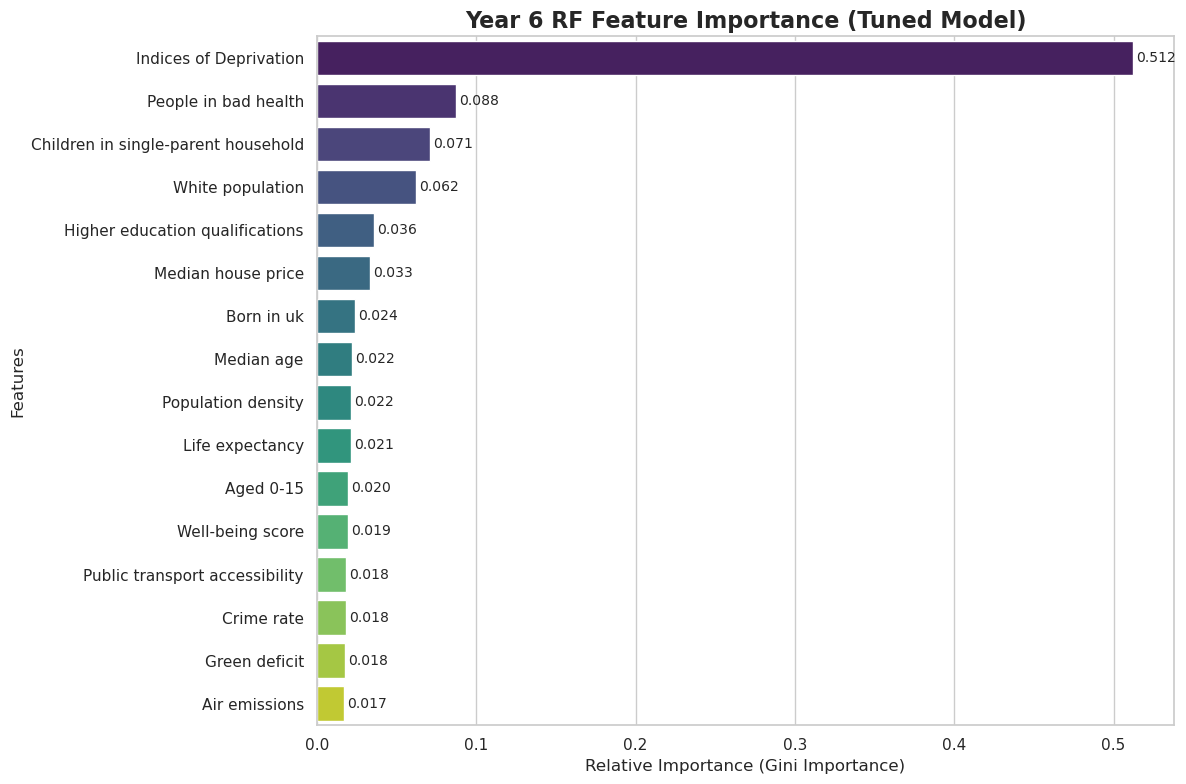

In [26]:
print("Year 6 RF — Starting CV and Hyperparameter Search...")
grid_search_rf_yr6 = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='r2',
    verbose=1
)

grid_search_rf_yr6.fit(X_train_yr6, y_train_yr6)

best_rf_yr6 = grid_search_rf_yr6.best_estimator_
print("\nBest Parameters:")
for key, value in grid_search_rf_yr6.best_params_.items():
    print(f" - {key}: {value}")

y_pred_rf_yr6 = best_rf_yr6.predict(X_test_yr6)

rmse_rf_yr6 = np.sqrt(mean_squared_error(y_test_yr6, y_pred_rf_yr6))
r2_rf_yr6 = r2_score(y_test_yr6, y_pred_rf_yr6)

print(f"Year 6 RF — R²: {r2_rf_yr6:.4f}, RMSE: {rmse_rf_yr6:.4f}")

importances_yr6 = best_rf_yr6.feature_importances_

importance_df_yr6 = pd.DataFrame({'Feature': X_train_yr6.columns, 'Importance': importances_yr6})
importance_df_yr6 = importance_df_yr6.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_yr6, hue='Feature', palette='viridis', legend=False)

plt.title('Year 6 RF Feature Importance (Tuned Model)', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance (Gini Importance)', fontsize=12)
plt.ylabel('Features', fontsize=12)

for index, value in enumerate(importance_df_yr6['Importance']):
    plt.text(value + 0.002, index, f'{value:.3f}', va='center', fontsize=10)
    
plt.tight_layout()
plt.show()

For Year 6, the tuned Random Forest (n_estimators=300, max_depth=10) achieves a test R² of 0.682 and RMSE of 2.693, again marginally improving over MLR (ΔR²=+0.006).

#### XGBoost
##### For Reception

In [27]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 MB 29.8 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 30.4 MB/s  0:00:09m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]


Reception XGBoost — Starting CV and Hyperparameter Search...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters:
 - colsample_bytree: 0.8
 - learning_rate: 0.05
 - max_depth: 5
 - n_estimators: 100
 - subsample: 0.8
Reception XGBoost — R²: 0.5800, RMSE: 2.1006


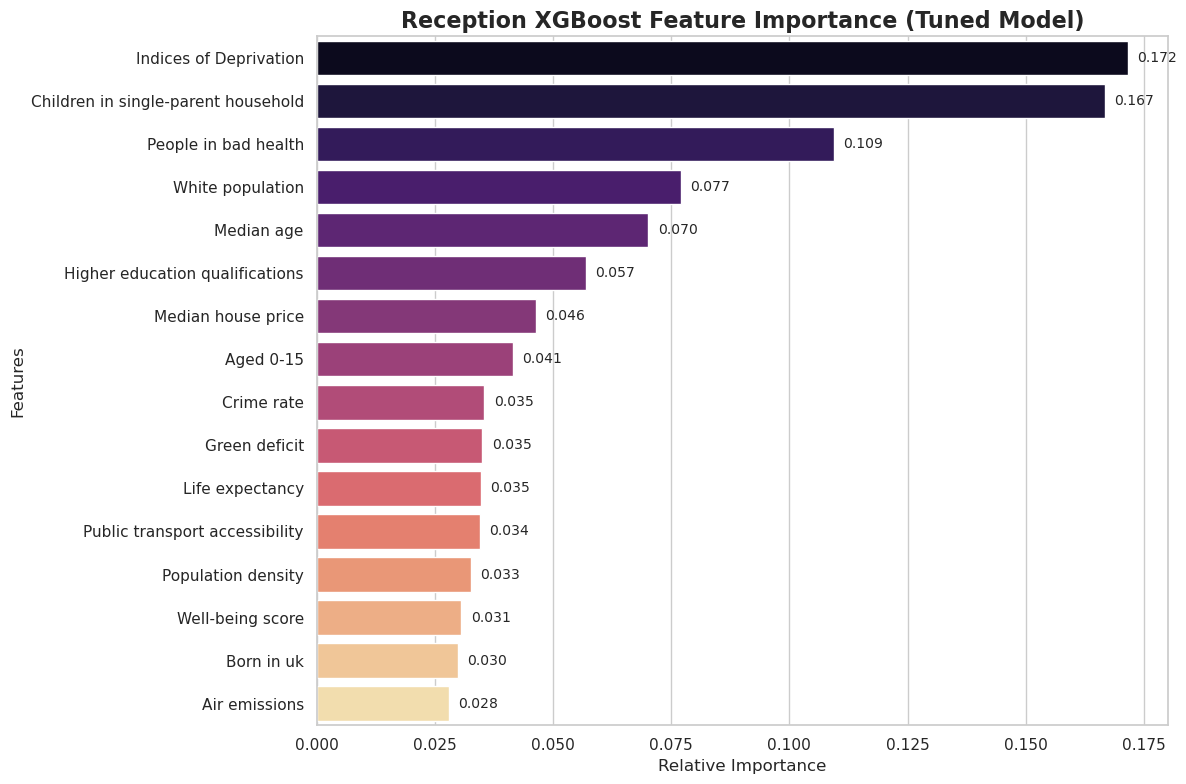

In [28]:
import xgboost as xgb

# Define the hyperparameter search grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize the base XGBoost model
xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror')

# Configure 5-Fold Cross-Validation
print("Reception XGBoost — Starting CV and Hyperparameter Search...")
grid_search_xgb_rec = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=5,
    n_jobs=-1,
    scoring='r2',
    verbose=1
)

# Fit GridSearchCV on the training data
grid_search_xgb_rec.fit(X_train_rec, y_train_rec)

# Extract the best model and optimal parameters
best_xgb_rec = grid_search_xgb_rec.best_estimator_

print("\nBest Parameters:")
for key, value in grid_search_xgb_rec.best_params_.items():
    print(f" - {key}: {value}")

# Test set prediction and evaluation
y_pred_xgb_rec = best_xgb_rec.predict(X_test_rec)

rmse_xgb_rec = np.sqrt(mean_squared_error(y_test_rec, y_pred_xgb_rec))
r2_xgb_rec = r2_score(y_test_rec, y_pred_xgb_rec)

print(f"Reception XGBoost — R²: {r2_xgb_rec:.4f}, RMSE: {rmse_xgb_rec:.4f}")

# Plot XGBoost feature importance
importances_xgb_rec = best_xgb_rec.feature_importances_

importance_df_xgb_rec = pd.DataFrame({'Feature': X_train_rec.columns, 'Importance': importances_xgb_rec})
importance_df_xgb_rec = importance_df_xgb_rec.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_xgb_rec, hue='Feature', palette='magma', legend=False)

plt.title('Reception XGBoost Feature Importance (Tuned Model)', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)

for index, value in enumerate(importance_df_xgb_rec['Importance']):
    plt.text(value + 0.002, index, f'{value:.3f}', va='center', fontsize=10)
    
plt.tight_layout()
plt.show()

XGBoost achieves the best Reception performance (R²=0.580, RMSE=2.101) with an optimal configuration of n_estimators=100, max_depth=5, learning_rate=0.05. As the best-performing model, it is selected as the basis for SHAP interpretation.

##### For Year 6

Year 6 XGBoost — Starting CV and Hyperparameter Search...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters:
 - colsample_bytree: 0.8
 - learning_rate: 0.01
 - max_depth: 5
 - n_estimators: 500
 - subsample: 0.8
Year 6 XGBoost — R²: 0.6831, RMSE: 2.6887


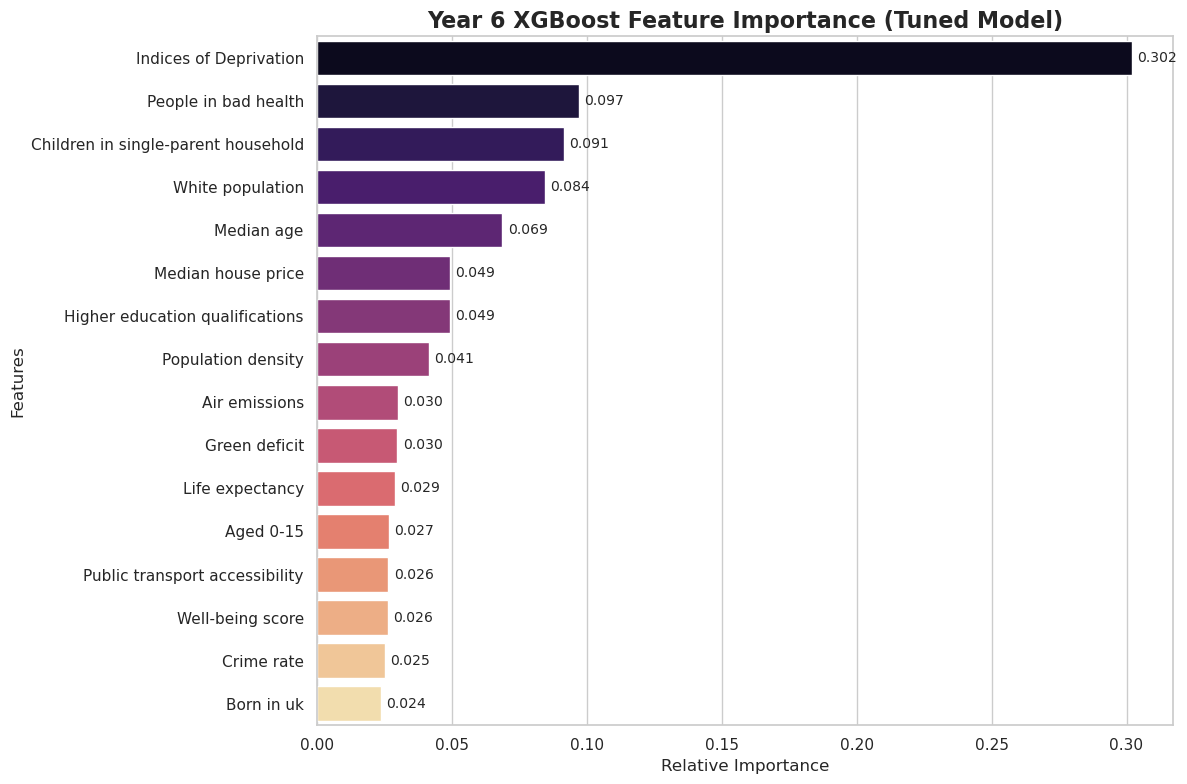

In [29]:
print("Year 6 XGBoost — Starting CV and Hyperparameter Search...")
grid_search_xgb_yr6 = GridSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror'),
    param_grid=param_grid_xgb,
    cv=5,
    n_jobs=-1,
    scoring='r2',
    verbose=1
)

grid_search_xgb_yr6.fit(X_train_yr6, y_train_yr6)

best_xgb_yr6 = grid_search_xgb_yr6.best_estimator_
print("\nBest Parameters:")
for key, value in grid_search_xgb_yr6.best_params_.items():
    print(f" - {key}: {value}")

y_pred_xgb_yr6 = best_xgb_yr6.predict(X_test_yr6)

rmse_xgb_yr6 = np.sqrt(mean_squared_error(y_test_yr6, y_pred_xgb_yr6))
r2_xgb_yr6 = r2_score(y_test_yr6, y_pred_xgb_yr6)

print(f"Year 6 XGBoost — R²: {r2_xgb_yr6:.4f}, RMSE: {rmse_xgb_yr6:.4f}")

importances_xgb_yr6 = best_xgb_yr6.feature_importances_

importance_df_xgb_yr6 = pd.DataFrame({'Feature': X_train_yr6.columns, 'Importance': importances_xgb_yr6})
importance_df_xgb_yr6 = importance_df_xgb_yr6.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_xgb_yr6, hue='Feature', palette='magma', legend=False)

plt.title('Year 6 XGBoost Feature Importance (Tuned Model)', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)

for index, value in enumerate(importance_df_xgb_yr6['Importance']):
    plt.text(value + 0.002, index, f'{value:.3f}', va='center', fontsize=10)
    
plt.tight_layout()
plt.show()

For Year 6, XGBoost again achieves the highest performance (R²=0.683, RMSE=2.689), with n_estimators=500, max_depth=5, learning_rate=0.01. It is similarly selected for subsequent SHAP analysis.

#### Model Performance Comparison

In [30]:
from IPython.display import display

# ── Reception: Model Performance Comparison ──
results_rec = pd.DataFrame({
    'Model': ['Multiple Linear Regression (MLR)', 'Random Forest (Tuned)', 'XGBoost (Tuned)'],
    'R-squared (R²)': [r2_mlr_rec, r2_rf_rec, r2_xgb_rec],
    'RMSE': [rmse_mlr_rec, rmse_rf_rec, rmse_xgb_rec],
    'Model Type': ['Linear / Baseline', 'Non-linear / Ensemble (Bagging)', 'Non-linear / Ensemble (Boosting)']
})

# Round for readability
results_rec = results_rec.round({'R-squared (R²)': 4, 'RMSE': 4})

print("Reception: Model Performance Comparison")
display(results_rec)

# ── Year 6: Model Performance Comparison ──
results_yr6 = pd.DataFrame({
    'Model': ['Multiple Linear Regression (MLR)', 'Random Forest (Tuned)', 'XGBoost (Tuned)'],
    'R-squared (R²)': [r2_mlr_yr6, r2_rf_yr6, r2_xgb_yr6],
    'RMSE': [rmse_mlr_yr6, rmse_rf_yr6, rmse_xgb_yr6],
    'Model Type': ['Linear / Baseline', 'Non-linear / Ensemble (Bagging)', 'Non-linear / Ensemble (Boosting)']
})

results_yr6 = results_yr6.round({'R-squared (R²)': 4, 'RMSE': 4})

print("Year 6: Model Performance Comparison")
display(results_yr6)

# ── Combined comparison across both cohorts (for Results & Discussion) ──
# This table merges both cohorts side by side for easy cross-group comparison
results_combined = pd.DataFrame({
    'Model': ['Multiple Linear Regression (MLR)', 'Random Forest (Tuned)', 'XGBoost (Tuned)'],
    'Reception R²': [r2_mlr_rec, r2_rf_rec, r2_xgb_rec],
    'Reception RMSE': [rmse_mlr_rec, rmse_rf_rec, rmse_xgb_rec],
    'Year 6 R²': [r2_mlr_yr6, r2_rf_yr6, r2_xgb_yr6],
    'Year 6 RMSE': [rmse_mlr_yr6, rmse_rf_yr6, rmse_xgb_yr6],
})

results_combined = results_combined.round(4)

print("Combined: Reception vs Year 6")
display(results_combined)

Reception: Model Performance Comparison


,Model,R-squared (R²),RMSE,Model Type
0,Multiple Linear Regression (MLR),0.5735,2.1169,Linear / Baseline
1,Random Forest (Tuned),0.5788,2.1037,Non-linear / Ensemble (Bagging)
2,XGBoost (Tuned),0.5800,2.1006,Non-linear / Ensemble (Boosting)


Year 6: Model Performance Comparison


,Model,R-squared (R²),RMSE,Model Type
0,Multiple Linear Regression (MLR),0.6756,2.7200,Linear / Baseline
1,Random Forest (Tuned),0.6822,2.6925,Non-linear / Ensemble (Bagging)
2,XGBoost (Tuned),0.6831,2.6887,Non-linear / Ensemble (Boosting)


Combined: Reception vs Year 6


,Model,Reception R²,Reception RMSE,Year 6 R²,Year 6 RMSE
0,Multiple Linear Regression (MLR),0.5735,2.1169,0.6756,2.7200
1,Random Forest (Tuned),0.5788,2.1037,0.6822,2.6925
2,XGBoost (Tuned),0.5800,2.1006,0.6831,2.6887


Across both cohorts, Year 6 obesity is consistently more predictable than Reception (R²≈0.68 vs ≈0.58), suggesting that ward-level features accumulate greater explanatory power as children age, while Reception obesity may be more strongly driven by individual-level factors not captured in area-level data. Within each cohort, performance gains from MLR to XGBoost are consistent but modest (ΔR²<0.01).

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

In [31]:
display(results_combined)

,Model,Reception R²,Reception RMSE,Year 6 R²,Year 6 RMSE
0,Multiple Linear Regression (MLR),0.5735,2.1169,0.6756,2.7200
1,Random Forest (Tuned),0.5788,2.1037,0.6822,2.6925
2,XGBoost (Tuned),0.5800,2.1006,0.6831,2.6887


XGBoost achieves the highest performance for both cohorts and is therefore selected as the basis for SHAP interpretation to address RQ2.

#### SHAP

In [32]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 MB 32.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 18.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]3/5 [numba]te]


##### For Reception

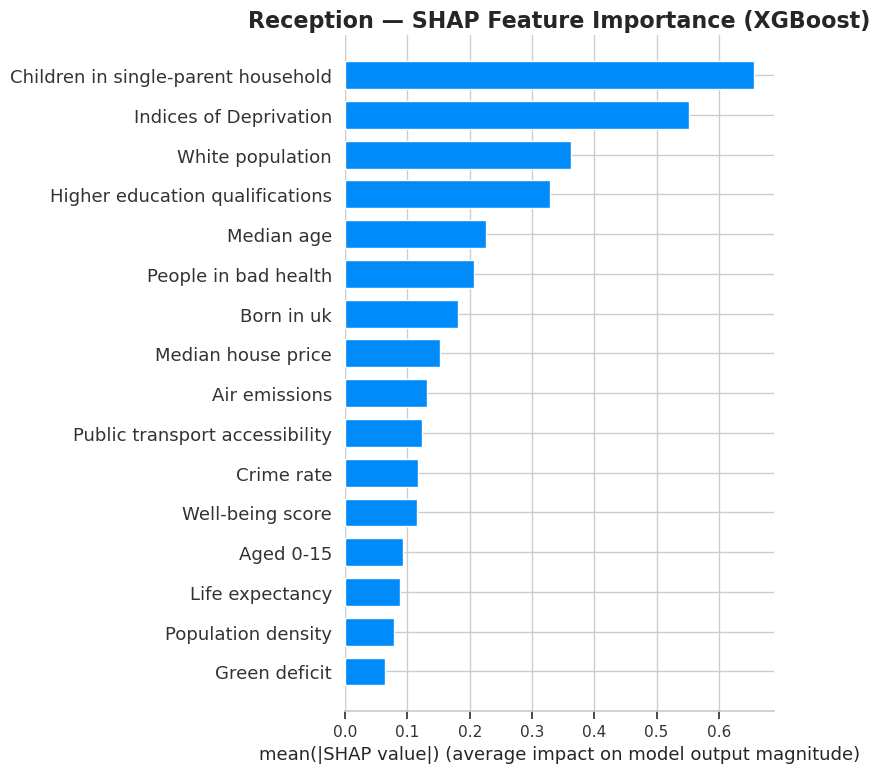

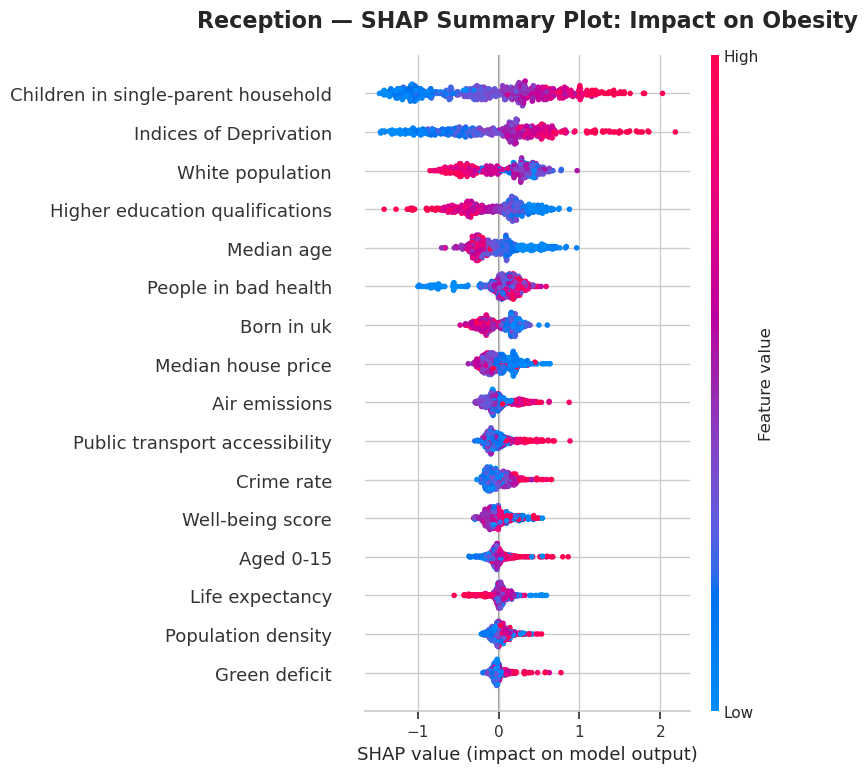

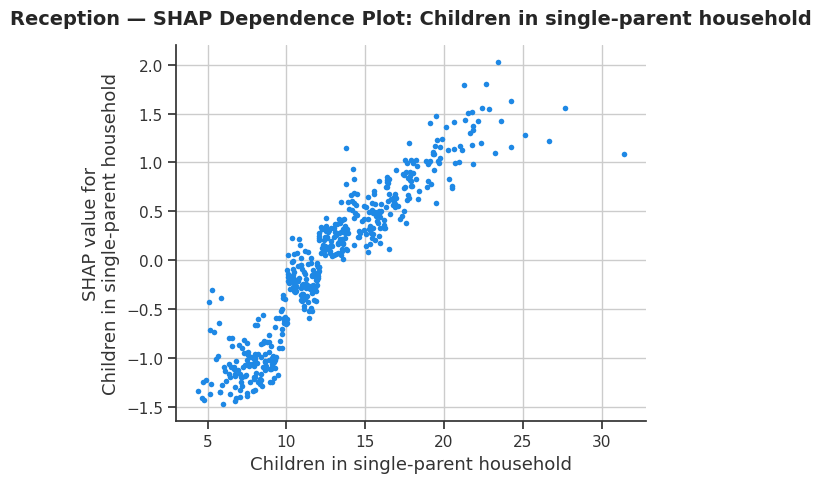

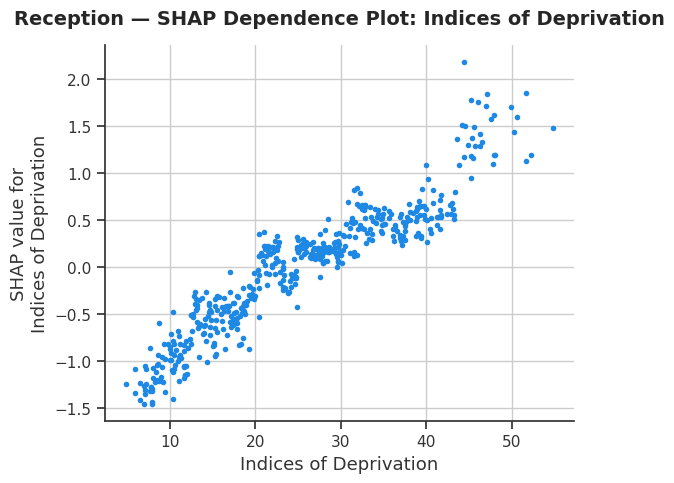

In [37]:
import shap
# I asked Claude about how to write SHAP codes
# Initialise TreeExplainer with the best XGBoost model for Reception
explainer_rec = shap.TreeExplainer(best_xgb_rec)

# Compute SHAP values on the training set for global interpretation
shap_values_rec = explainer_rec.shap_values(X_train_rec)

# Figure 1: Global feature importance bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rec, X_train_rec, plot_type="bar", show=False)
plt.title("Reception — SHAP Feature Importance (XGBoost)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 2: Beeswarm plot — shows direction and magnitude of each feature's impact
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rec, X_train_rec, show=False)
plt.title("Reception — SHAP Summary Plot: Impact on Obesity", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Figure 3: Dependence plots for the top 2 features — explore nonlinear marginal effects
# Update feature names below if Reception's top features differ from Year 6
top_feature_1_rec = 'Children in single-parent household'
top_feature_2_rec = 'Indices of Deprivation'

shap.dependence_plot(top_feature_1_rec, shap_values_rec, X_train_rec, interaction_index=None, show=False)
plt.title(f"Reception — SHAP Dependence Plot: {top_feature_1_rec}", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

shap.dependence_plot(top_feature_2_rec, shap_values_rec, X_train_rec, interaction_index=None, show=False)
plt.title(f"Reception — SHAP Dependence Plot: {top_feature_2_rec}", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Children in single-parent household and Indices of Deprivation are the dominant drivers for Reception (mean |SHAP| ≈0.65 and ≈0.55), both positively associated with obesity. Higher education qualifications exerts a strong negative influence, reflecting the protective role of parental human capital in early childhood. 

The Children in single-parent household dependence plot reveals a nonlinear positive relationship, with SHAP values turning strongly positive beyond ~15%. The Indices of Deprivation plot confirms a near-monotonic positive relationship (SHAP range: -1.5 to +2.0).

##### For Year 6

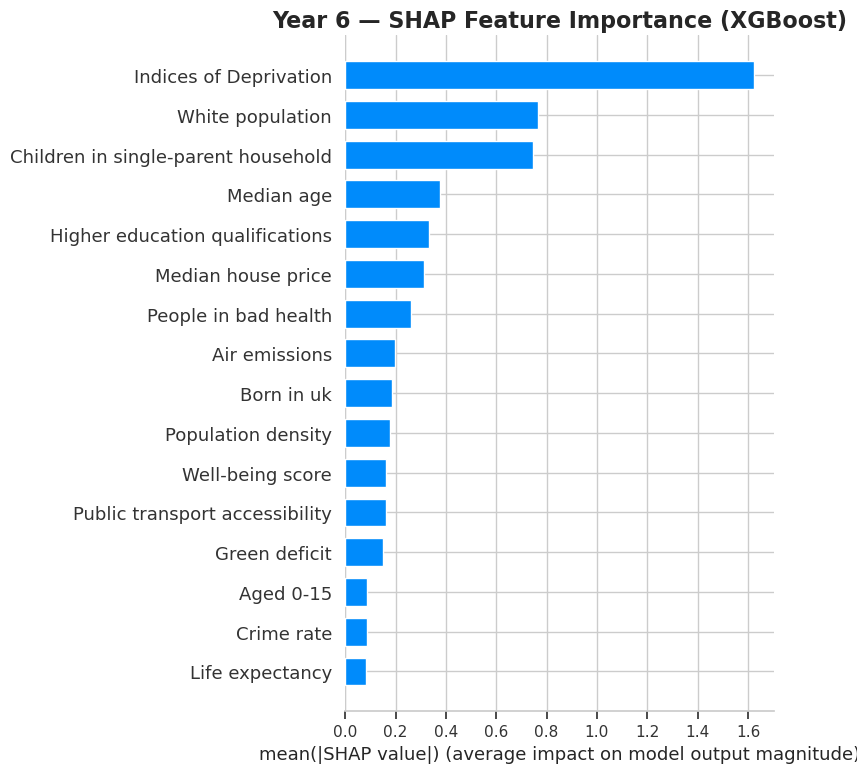

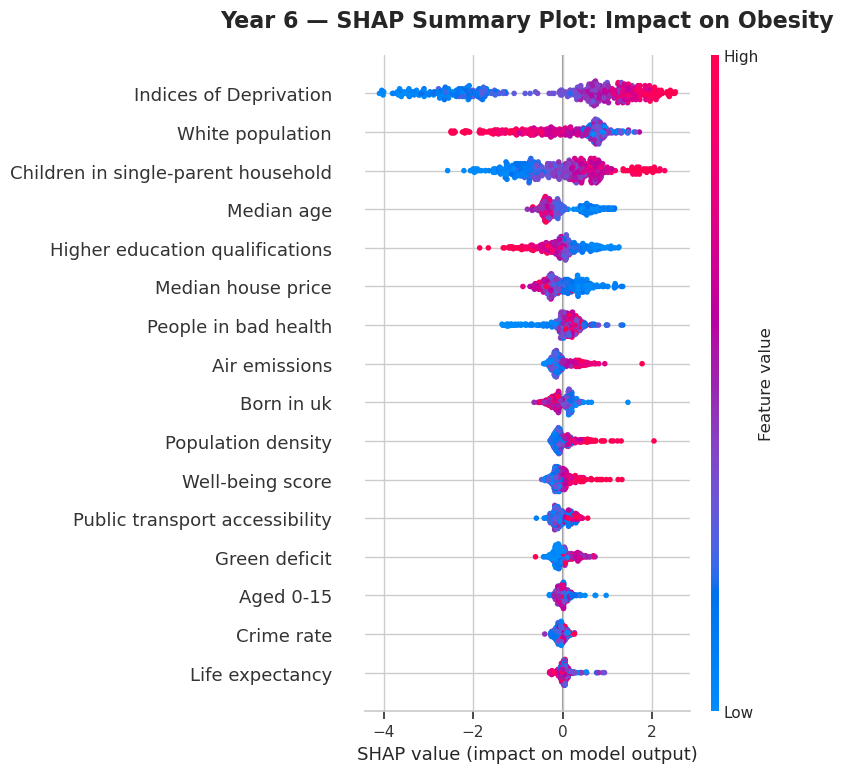

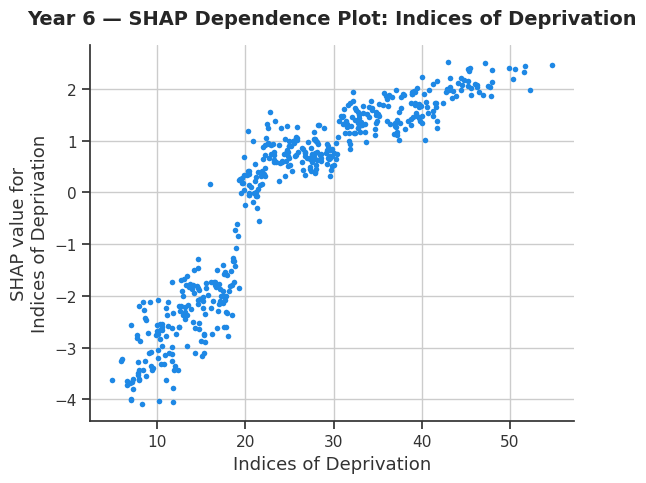

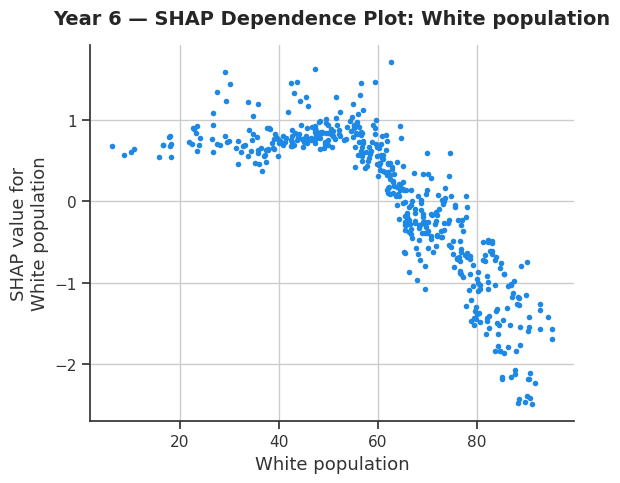

In [36]:
# Initialise TreeExplainer with the best XGBoost model for Year 6
explainer_yr6 = shap.TreeExplainer(best_xgb_yr6)

# Compute SHAP values on the training set for global interpretation
shap_values_yr6 = explainer_yr6.shap_values(X_train_yr6)

# Figure 1: Global feature importance bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_yr6, X_train_yr6, plot_type="bar", show=False)
plt.title("Year 6 — SHAP Feature Importance (XGBoost)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 2: Beeswarm plot — shows direction and magnitude of each feature's impact
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_yr6, X_train_yr6, show=False)
plt.title("Year 6 — SHAP Summary Plot: Impact on Obesity", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Figure 3: Dependence plots for the top 2 features — explore nonlinear marginal effects
# Update feature names below after inspecting the bar plot above
top_feature_1_yr6 = 'Indices of Deprivation'
top_feature_2_yr6 = 'White population'

shap.dependence_plot(top_feature_1_yr6, shap_values_yr6, X_train_yr6, interaction_index=None, show=False)
plt.title(f"Year 6 — SHAP Dependence Plot: {top_feature_1_yr6}", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

shap.dependence_plot(top_feature_2_yr6, shap_values_yr6, X_train_yr6, interaction_index=None, show=False)
plt.title(f"Year 6 — SHAP Dependence Plot: {top_feature_2_yr6}", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Indices of Deprivation remains the overwhelmingly dominant driver in Year 6 (mean |SHAP| ≈1.60, range: -4.0 to +2.5), substantially wider than Reception, consistent with cumulative neighbourhood deprivation effects over childhood. White population emerges second (≈0.75), showing a clear threshold: SHAP values remain positive below ~60% but drop sharply thereafter, suggesting that higher White population proportions, a proxy for socioeconomic advantage in London, exert a strong protective effect against obesity by Year 6.

#### Comparison and Discussion
Comparing cohorts directly addresses RQ2. Indices of Deprivation rises from second to first, with mean |SHAP| nearly tripling (0.55→1.60), consistent with a cumulative deprivation hypothesis: obesogenic neighbourhood effects compound over childhood and become increasingly detectable by Year 6. 

Conversely, Children in single-parent household drops from first to third, suggesting family structure is most influential in early childhood when parental feeding practices dominate, and diminishes as children gain autonomy and become more exposed to school environments. 

These findings underscore the need for stage-specific interventions: **family-focused policies in early years, and neighbourhood deprivation reduction strategies as children approach adolescence**.

#### Limitation
This study has several limitations. Reliance on area-level data excludes individual-level predictors such as diet and physical activity, likely explaining the moderate R² ceiling. The cross-sectional design also precludes causal inference. Future research should integrate individual-level records with area-level data and adopt longitudinal designs.

## Conclusion

[[ go back to the top ]](#Table-of-contents)

This study employed VIF, MLR, Random Forest, XGBoost, and SHAP to investigate the ward-level drivers of childhood obesity across Reception and Year 6 cohorts in London. XGBoost achieved the best predictive performance for both groups (R²=0.580 and 0.683 respectively), with Year 6 consistently more predictable than Reception. SHAP analysis revealed a clear developmental shift in key drivers: family structure (Children in single-parent household) dominates in early childhood, while neighbourhood deprivation (Indices of Deprivation) becomes overwhelmingly influential by Year 6. These findings suggest that effective interventions should be stage-specific: prioritising family support in early years and broader deprivation reduction strategies as children age.

In [35]:
end_time = time.time() 
run_time = end_time - start_time 
print("Total run time: ", run_time, "seconds")

Total run time:  305.47827553749084 seconds


## References

[[ go back to the top ]](#Table-of-contents)

Colmenarejo, G. (2020) ‘Machine Learning Models to Predict Childhood and Adolescent Obesity: A Review’, Nutrients, 12(8). Available at: https://doi.org/10.3390/nu12082466.

National Child Measurement Programme annual report, academic year 2024 to 2025 (no date). Available at: https://fingertips.phe.org.uk/static-reports/obesity-physical-activity-nutrition/national-child-measurement-programme-2024-2025-academic-year.html (Accessed: 8 April 2026).

Pei, Z. et al. (2013) ‘Early life risk factors of being overweight at 10 years of age: results of the German birth cohorts GINIplus and LISAplus’, European Journal of Clinical Nutrition, 67(8), pp. 855–862. Available at: https://doi.org/10.1038/ejcn.2013.80.

Hammond R. et al. (2019) ‘Predicting childhood obesity using electronic health records and publicly available data’, PLOS ONE, 14(4), p. e0215571. Available at: https://doi.org/10.1371/journal.pone.0215571.

Jeong, S. et al. (2023) ‘Understanding cross-data dynamics of individual and social/environmental factors through a public health lens: explainable machine learning approaches’, Frontiers in Public Health, 11. Available at: https://doi.org/10.3389/fpubh.2023.1257861.

Mazza, O. et al. (2025) ‘Spatial patterns of childhood obesity clusters linked to socioeconomic inequalities’, Frontiers in Public Health, 13. Available at: https://doi.org/10.3389/fpubh.2025.1497090.

Salerno, P.R.V.O. et al. (2024) ‘County-level socio-environmental factors and obesity prevalence in the United States’, Diabetes, Obesity and Metabolism, 26(5), pp. 1766–1774. Available at: https://doi.org/10.1111/dom.15488.
